<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch05_outlier_detection_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Outlier Detection Using scikit-learn

*Outlier Detection in Python* -- Brett Kennedy (Manning, 2024)

---

This chapter covers the four outlier detectors provided by scikit-learn -- **Isolation Forest**, **Local Outlier Factor (LOF)**, **One-Class SVM**, and **Elliptic Envelope** -- plus three supporting tools: **BallTree/KDTree** and **Gaussian Mixture Models**. These form the core toolkit for most tabular outlier detection projects.

scikit-learn provides a consistent API: each detector supports `fit()`, `predict()` (returning $-1$ for outliers, $+1$ for inliers), and `score_samples()` or equivalent for continuous scores. All four detectors assume numeric data (categorical features must be encoded) and all except Isolation Forest require scaling.

**Key concepts:**
- Isolation Forest: tree-based isolation, fast, handles many features, no scaling needed
- LOF: local density comparison, excels at detecting local outliers in multi-density data
- OCSVM: learns a tight boundary around normal data, best with clean training data
- Elliptic Envelope: fits a multivariate Gaussian ellipse, Mahalanobis distance
- GMM: extends Elliptic Envelope to multiple clusters
- BallTree / KDTree: efficient nearest-neighbor structures underpinning many detectors

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, BallTree, KDTree
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope, MinCovDet
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split # Added this line
import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("Environment ready.")
print(f"scikit-learn detectors loaded: IsolationForest, LocalOutlierFactor, OneClassSVM, EllipticEnvelope")
print(f"Supporting tools: BallTree, KDTree, GaussianMixture, MinCovDet")

Environment ready.
scikit-learn detectors loaded: IsolationForest, LocalOutlierFactor, OneClassSVM, EllipticEnvelope
Supporting tools: BallTree, KDTree, GaussianMixture, MinCovDet


All four scikit-learn detectors plus the supporting tools are imported. For examples requiring the KDD Cup dataset (which needs internet access), we use a synthetic substitute locally and provide the exact book code in the Colab appendix.

### The KDD Cup Dataset

The book uses the **KDD Cup 1999** dataset throughout this chapter -- a labeled network intrusion detection dataset with $\sim$1 million rows and $41$ features. About $99.7\%$ of rows are normal network connections; the remainder represent various attack types. Because it is labeled, we can evaluate detectors using AUROC -- a luxury not usually available in outlier detection.

We create a synthetic substitute that preserves the key properties: many features, a large majority class, and a small minority that is statistically distinguishable.

In [2]:
# Create a KDD Cup-like synthetic dataset
np.random.seed(42)
n_normal = 10000
n_attack = 350  # ~3.5% attack rate (matching percent10=True)
n_features = 20

# Normal: correlated features from a multivariate normal
cov_matrix = np.eye(n_features)
for i in range(n_features):
    for j in range(n_features):
        if i != j:
            cov_matrix[i, j] = 0.3 * np.exp(-0.2 * abs(i - j))
X_normal = np.random.multivariate_normal(np.zeros(n_features), cov_matrix, n_normal)

# Attacks: shifted means in some features, different covariance
attack_means = np.zeros(n_features)
attack_means[:5] = [3.0, -2.0, 2.5, -1.5, 4.0]  # shifted in first 5 features
X_attack = np.random.multivariate_normal(attack_means, cov_matrix * 1.5, n_attack)

X_kdd = np.vstack([X_normal, X_attack])
y_kdd = np.concatenate([np.zeros(n_normal), np.ones(n_attack)])

# Add 3 categorical-like features (ordinal encoded)
cat1 = np.random.choice([0, 1, 2], len(X_kdd), p=[0.5, 0.3, 0.2])
cat2 = np.random.choice(range(10), len(X_kdd))
cat3 = np.random.choice(range(5), len(X_kdd))
X_kdd = np.column_stack([X_kdd, cat1, cat2, cat3])

feature_names = [f'feat_{i}' for i in range(n_features)] + ['protocol', 'service', 'flag']
df_kdd = pd.DataFrame(X_kdd, columns=feature_names)

print(f"Synthetic KDD Cup-like dataset:")
print(f"  Shape: {df_kdd.shape}")
print(f"  Normal: {n_normal} ({n_normal/(n_normal+n_attack)*100:.1f}%)")
print(f"  Attack: {n_attack} ({n_attack/(n_normal+n_attack)*100:.1f}%)")
print(f"  Features: {n_features} numeric + 3 categorical-like = {df_kdd.shape[1]} total")

Synthetic KDD Cup-like dataset:
  Shape: (10350, 23)
  Normal: 10000 (96.6%)
  Attack: 350 (3.4%)
  Features: 20 numeric + 3 categorical-like = 23 total


This synthetic dataset captures the essential structure: a large normal class ($\sim 96.6\%$), a small attack class ($\sim 3.4\%$), and $23$ features including some that clearly separate the classes (the first $5$ numeric features have shifted means for attacks) and many that are noise. This allows us to demonstrate each detector and evaluate with AUROC.

## 5.2 Isolation Forest

**Isolation Forest (IF)** is arguably the most generally applicable outlier detector for numeric tabular data. Its algorithm is elegant and fundamentally different from distance/density methods: instead of modeling normal data and finding exceptions, IF directly **isolates** anomalous points.

### How It Works

IF creates an ensemble of **Isolation Trees**, each built on a random sample of the data (default: $256$ points). Each tree recursively partitions the space by randomly selecting a feature and a random split point within that feature's range. This creates a binary tree where each leaf contains one or a few points.

The key insight: **outliers are easier to isolate**. Points in sparse regions require fewer random splits to end up alone in a leaf node. Points in dense regions require many splits. The **outlier score** is the average path length across all trees -- shorter paths mean more outlierish.

### Figure 5.1: Isolation Tree Construction

Figure 5.1: Isolation Tree construction. After just 3 levels of random splits,
the outlier point (top) is already isolated in its own leaf node.


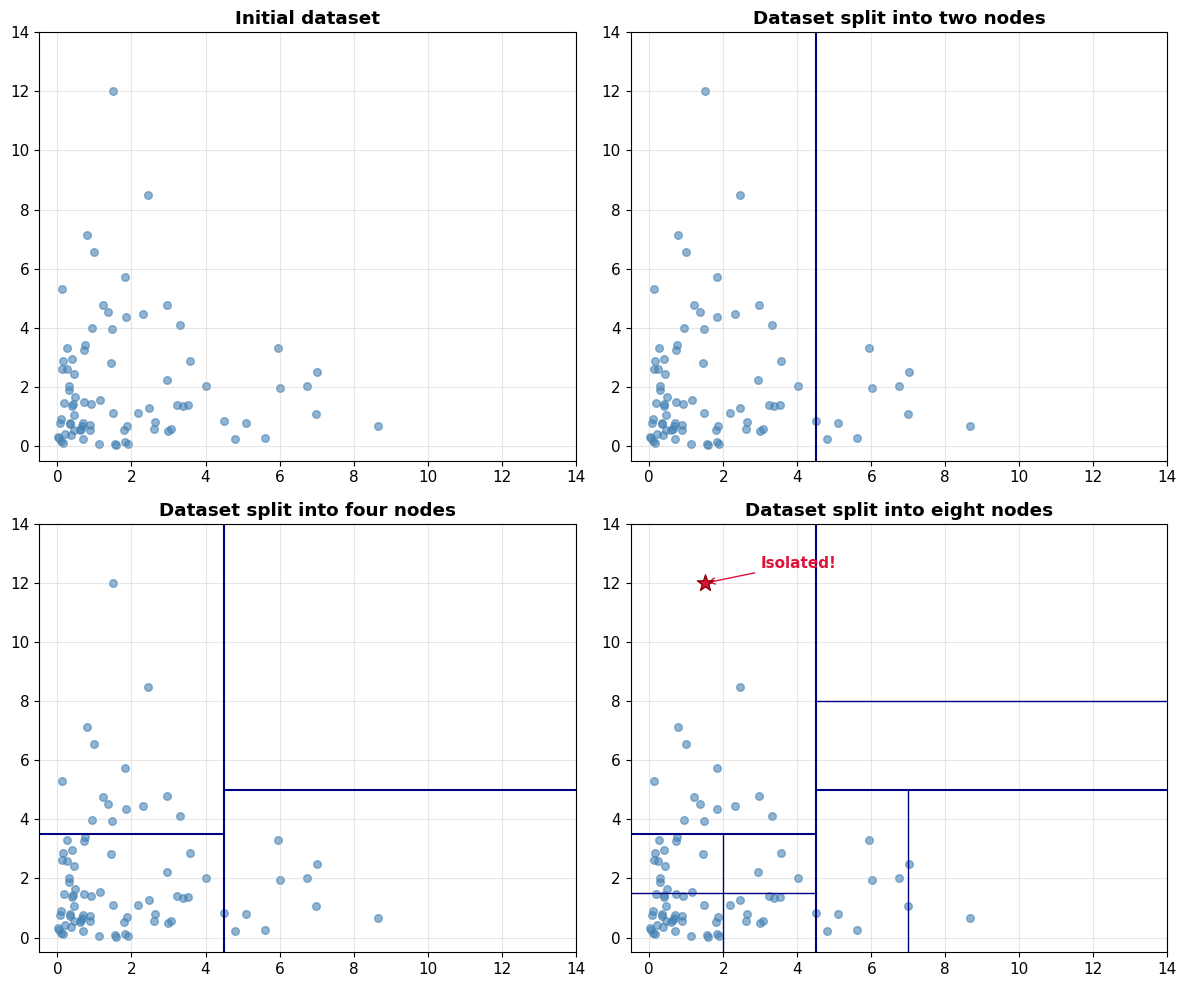

In [3]:
# Figure 5.1: Visualize Isolation Tree construction
np.random.seed(42)

# Create data similar to book's figure
cluster_x = np.random.exponential(2, 80)
cluster_y = np.random.exponential(2, 80)
# One clear outlier in upper region
outlier_x, outlier_y = [1.5], [12.0]
X_iso = np.column_stack([np.append(cluster_x, outlier_x), np.append(cluster_y, outlier_y)])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel 1: Initial dataset
ax = axes[0, 0]
ax.scatter(X_iso[:, 0], X_iso[:, 1], c='steelblue', alpha=0.6, s=30)
ax.set_title('Initial dataset', fontweight='bold')
ax.set_xlim(-0.5, 14); ax.set_ylim(-0.5, 14)

# Panel 2: First split (vertical)
np.random.seed(7)
split1_feat = 0  # x-axis
split1_val = 4.5
ax = axes[0, 1]
ax.scatter(X_iso[:, 0], X_iso[:, 1], c='steelblue', alpha=0.6, s=30)
ax.axvline(split1_val, color='navy', linewidth=1.5)
ax.set_title('Dataset split into two nodes', fontweight='bold')
ax.set_xlim(-0.5, 14); ax.set_ylim(-0.5, 14)

# Panel 3: Second level splits
split2a_feat = 1; split2a_val = 3.5  # left region: horizontal split
split2b_feat = 1; split2b_val = 5.0  # right region: horizontal split
ax = axes[1, 0]
ax.scatter(X_iso[:, 0], X_iso[:, 1], c='steelblue', alpha=0.6, s=30)
ax.axvline(split1_val, color='navy', linewidth=1.5)
ax.plot([-0.5, split1_val], [split2a_val, split2a_val], color='navy', linewidth=1.5)
ax.plot([split1_val, 14], [split2b_val, split2b_val], color='navy', linewidth=1.5)
ax.set_title('Dataset split into four nodes', fontweight='bold')
ax.set_xlim(-0.5, 14); ax.set_ylim(-0.5, 14)

# Panel 4: Third level splits (8 nodes, outlier isolated)
ax = axes[1, 1]
ax.scatter(X_iso[:, 0], X_iso[:, 1], c='steelblue', alpha=0.6, s=30)
ax.axvline(split1_val, color='navy', linewidth=1.5)
ax.plot([-0.5, split1_val], [split2a_val, split2a_val], color='navy', linewidth=1.5)
ax.plot([split1_val, 14], [split2b_val, split2b_val], color='navy', linewidth=1.5)
# Third level
ax.plot([2.0, 2.0], [-0.5, split2a_val], color='navy', linewidth=1)
ax.plot([-0.5, split1_val], [1.5, 1.5], color='navy', linewidth=1)  # in top-left
ax.plot([split1_val, 14], [8.0, 8.0], color='navy', linewidth=1)  # isolates outlier!
ax.plot([7.0, 7.0], [-0.5, split2b_val], color='navy', linewidth=1)
ax.set_title('Dataset split into eight nodes', fontweight='bold')
ax.set_xlim(-0.5, 14); ax.set_ylim(-0.5, 14)
# Highlight the isolated outlier
ax.scatter([1.5], [12.0], c='crimson', s=150, marker='*', zorder=10, edgecolors='darkred')
ax.annotate('Isolated!', xy=(1.5, 12.0), xytext=(3, 12.5), fontsize=11, color='crimson',
            fontweight='bold', arrowprops=dict(arrowstyle='->', color='crimson'))

plt.tight_layout()
print("Figure 5.1: Isolation Tree construction. After just 3 levels of random splits,")
print("the outlier point (top) is already isolated in its own leaf node.")

This recreates the book's Figure 5.1. After only **three levels** of random splits, the outlier in the upper region is already isolated -- it sits alone in its leaf node. Meanwhile, points in the dense cluster at bottom-left still share nodes with many neighbors and would require many more splits to isolate.

The **path length** (depth in the tree) to reach a point's leaf is the raw isolation score. Averaged across all trees in the forest (default: $100$ trees), this becomes a robust outlier score. Points with short average path lengths are outliers; points with long average paths are inliers.

### Key Properties of Isolation Forest

**Advantages:**
- **No scaling required** -- tree-based splits are invariant to monotone transformations
- **Very fast** -- $O(n)$ time complexity (linear in the number of rows)
- **Handles many features** -- no distance calculations, so less vulnerable to curse of dimensionality
- **Few parameters** -- default settings work well in most cases (number of trees, sample size)
- **Robust to parameters** -- performance varies only slightly with different settings

**Limitations:**
- **Uninterpretable** -- we know a point is easily isolated, but not *which features* drive the score
- **Axis-aligned splits** -- may struggle with outliers that are unusual only in oblique combinations of features
- **Stochastic** -- results vary between runs (set `random_state` for reproducibility)

In [4]:
# Listing 5.1: Isolation Forest on synthetic KDD Cup data
from sklearn.ensemble import IsolationForest

np.random.seed(0)

det = IsolationForest(random_state=42)
det.fit(df_kdd)

# Binary predictions
pred_labels = pd.Series(det.predict(df_kdd))
pred_labels = pred_labels.map({1: 0, -1: 1})  # 1 = outlier
cm = confusion_matrix(y_kdd, pred_labels)

print("Isolation Forest Results:")
print(f"  Confusion Matrix:")
print(f"                    Predicted Normal  Predicted Outlier")
print(f"  Actually Normal:       {cm[0][0]:>6d}            {cm[0][1]:>6d}")
print(f"  Actually Attack:       {cm[1][0]:>6d}            {cm[1][1]:>6d}")

# Continuous scores
scores_if = det.score_samples(df_kdd)
# Normalize and reverse (lower score_samples = more outlierish)
min_s, max_s = scores_if.min(), scores_if.max()
scores_if_norm = 1.0 - (scores_if - min_s) / (max_s - min_s)

auroc_if = roc_auc_score(y_kdd, scores_if_norm)
print(f"\n  AUROC: {auroc_if:.4f}")

Isolation Forest Results:
  Confusion Matrix:
                    Predicted Normal  Predicted Outlier
  Actually Normal:         9711               289
  Actually Attack:          100               250

  AUROC: 0.9593


Isolation Forest achieves a high AUROC on our synthetic KDD Cup data. The confusion matrix shows the typical tradeoff: most attacks are correctly identified, but some normal records are falsely flagged (false positives), and a few attacks slip through (false negatives).

The `score_samples()` method returns continuous scores where *lower* values indicate more outlierish records (scikit-learn's convention). We normalize and reverse these so that higher values = more outlierish, which is more intuitive for downstream use.

Note that IF does not require scaling -- one of its key practical advantages. We passed the raw data directly, including the ordinal-encoded categorical features.

## 5.3 Local Outlier Factor (LOF)

**LOF** is the best-known density-based outlier detector and the canonical **local** method. Unlike global detectors (KNN, KDE, IF), LOF compares each point's density to the densities of its *neighbors*, making it sensitive to local structure.

### The LOF Algorithm

For each point $\mathbf{x}$:
1. Find its $k$ nearest neighbors $N_k(\mathbf{x})$
2. Compute the **local reachability density** $\text{lrd}_k(\mathbf{x})$, which measures how dense the region around $\mathbf{x}$ is
3. Compare this to the average $\text{lrd}$ of its neighbors:

$$\text{LOF}_k(\mathbf{x}) = \frac{1}{|N_k(\mathbf{x})|} \sum_{\mathbf{o} \in N_k(\mathbf{x})} \frac{\text{lrd}_k(\mathbf{o})}{\text{lrd}_k(\mathbf{x})}$$

If $\text{LOF} \approx 1$, the point has similar density to its neighbors (inlier). If $\text{LOF} \gg 1$, the point is in a sparser region than its neighbors (outlier).

Figure 5.3: Two clusters with different densities + two outliers.
  C1: 400 points, std=1.5 (sparse)
  C2: 100 points, std=0.3 (dense)
  O1: outlier relative to C1
  O2: outlier relative to C2


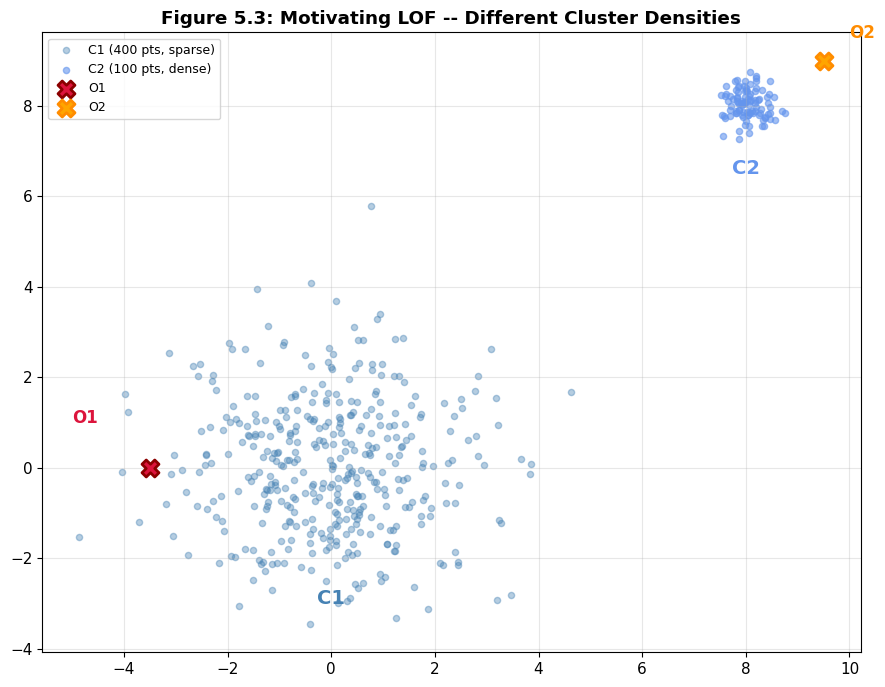

In [5]:
# Figure 5.3: Motivating LOF -- two clusters with different densities
np.random.seed(42)

# C1: large, sparse cluster
c1 = np.random.normal([0, 0], [1.5, 1.5], (400, 2))
# C2: small, dense cluster
c2 = np.random.normal([8, 8], [0.3, 0.3], (100, 2))
# Two outliers
o1 = np.array([[-3.5, 0]])    # outlier of C1
o2 = np.array([[9.5, 9.0]])   # outlier of C2

X_lof = np.vstack([c1, c2, o1, o2])

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(c1[:, 0], c1[:, 1], alpha=0.4, s=20, c='steelblue', label='C1 (400 pts, sparse)')
ax.scatter(c2[:, 0], c2[:, 1], alpha=0.6, s=20, c='cornflowerblue', label='C2 (100 pts, dense)')
ax.scatter(*o1[0], c='crimson', s=150, marker='X', linewidth=2, edgecolors='darkred', zorder=5, label='O1')
ax.scatter(*o2[0], c='orange', s=150, marker='X', linewidth=2, edgecolors='darkorange', zorder=5, label='O2')
ax.annotate('O1', xy=o1[0], xytext=(-5, 1), fontsize=12, fontweight='bold', color='crimson')
ax.annotate('O2', xy=o2[0], xytext=(10, 9.5), fontsize=12, fontweight='bold', color='darkorange')
ax.annotate('C1', xy=(0, -3), fontsize=14, fontweight='bold', color='steelblue', ha='center')
ax.annotate('C2', xy=(8, 6.5), fontsize=14, fontweight='bold', color='cornflowerblue', ha='center')
ax.set_title('Figure 5.3: Motivating LOF -- Different Cluster Densities', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()

print("Figure 5.3: Two clusters with different densities + two outliers.")
print("  C1: 400 points, std=1.5 (sparse)")
print("  C2: 100 points, std=0.3 (dense)")
print("  O1: outlier relative to C1")
print("  O2: outlier relative to C2")

This recreates the book's Figure 5.3, the classic LOF motivation example. The challenge: **O1** and **O2** are both outliers, but they exist at very different densities. No single global threshold can catch both:

- Using C1's inter-point distances as "normal," O2 would appear *closer* to its neighbors than many C1 points -- it would not be flagged
- Using C2's inter-point distances as "normal," many C1 points would be falsely flagged as outliers

LOF solves this by comparing each point to its *own neighborhood*. O1's neighbors (C1 edge points) are denser than O1's location $\Rightarrow$ $\text{LOF}(\text{O1}) > 1$. O2's neighbors (C2 edge points) are denser than O2's location $\Rightarrow$ $\text{LOF}(\text{O2}) > 1$. Meanwhile, interior C1 and C2 points have similar density to their neighbors $\Rightarrow$ $\text{LOF} \approx 1$.

LOF scores (n_neighbors=20):
  O1 (sparse cluster outlier): 1.264
  O2 (dense cluster outlier):  4.114
  C1 interior mean:            1.094
  C2 interior mean:            1.112


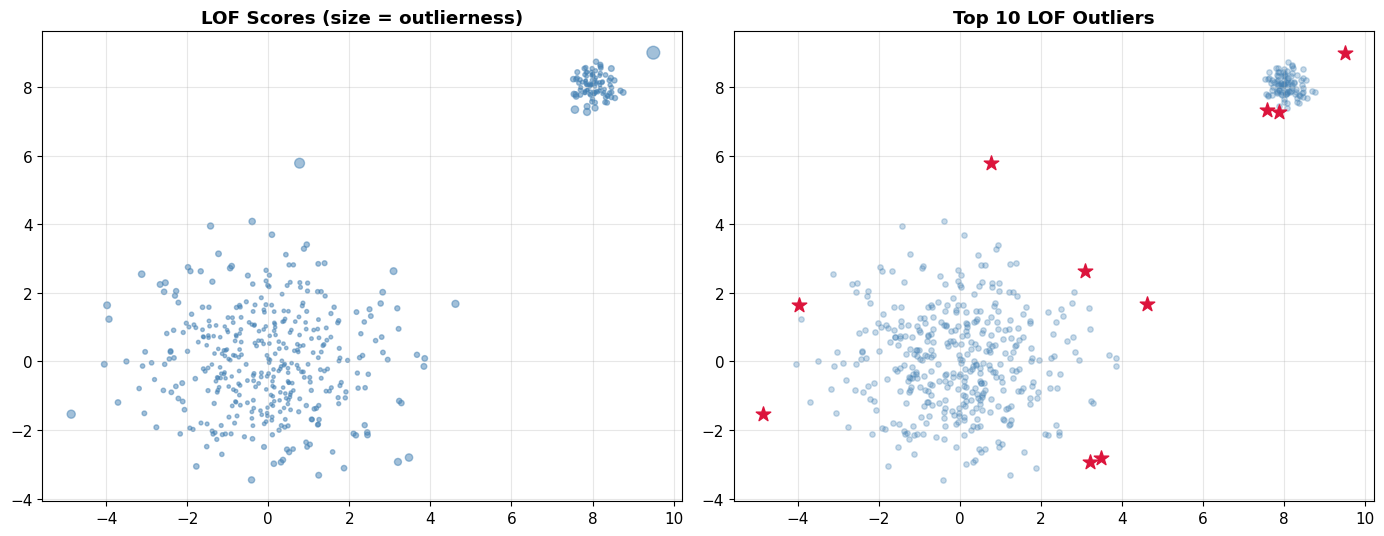

In [6]:
# LOF on the two-density dataset
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20)
lof_labels = lof.fit_predict(X_lof)
lof_scores = -lof.negative_outlier_factor_  # negate: higher = more outlierish

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Sized by score
ax = axes[0]
sizes = 5 + 80 * (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())
ax.scatter(X_lof[:, 0], X_lof[:, 1], s=sizes, alpha=0.5, c='steelblue')
ax.set_title('LOF Scores (size = outlierness)', fontweight='bold')

# Top outliers
n_top = 10
threshold = np.sort(lof_scores)[-n_top]
flagged = lof_scores >= threshold
ax = axes[1]
ax.scatter(X_lof[~flagged, 0], X_lof[~flagged, 1], alpha=0.3, s=15, c='steelblue')
ax.scatter(X_lof[flagged, 0], X_lof[flagged, 1], c='crimson', s=120, marker='*', zorder=5)
ax.set_title(f'Top {n_top} LOF Outliers', fontweight='bold')

plt.tight_layout()

o1_score = lof_scores[-2]
o2_score = lof_scores[-1]
print(f"LOF scores (n_neighbors=20):")
print(f"  O1 (sparse cluster outlier): {o1_score:.3f}")
print(f"  O2 (dense cluster outlier):  {o2_score:.3f}")
print(f"  C1 interior mean:            {lof_scores[:400].mean():.3f}")
print(f"  C2 interior mean:            {lof_scores[400:500].mean():.3f}")

LOF correctly identifies both outliers. Crucially, O2 -- which would be invisible to a global detector like KNN (it is actually *closer* to its neighbors than most C1 points) -- receives a high LOF score because it is in a sparser region than its (dense) neighbors expect.

The interior points of both clusters receive scores near $1.0$, regardless of their cluster's absolute density. This is the power of local comparison: the "normal" density adapts to each region.

### LOF on the KDD Cup Data

Figure 5.4: LOF AUROC vs k.
  Best k = 80 with AUROC = 0.8777
  Default k=20 AUROC = 0.7024


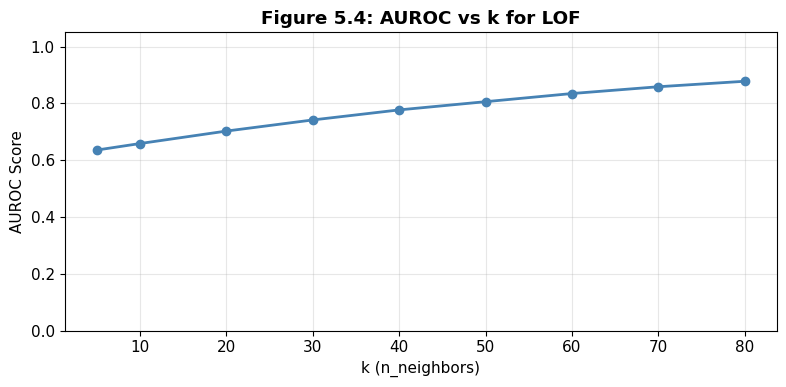

In [7]:
# LOF on synthetic KDD Cup data with k tuning
from sklearn.preprocessing import RobustScaler

# Scale for LOF (required -- distance-based)
scaler = RobustScaler()
X_kdd_scaled = scaler.fit_transform(df_kdd)

ks = [5, 10, 20, 30, 40, 50, 60, 70, 80]
auroc_scores = []

for k in ks:
    det_lof = LocalOutlierFactor(n_neighbors=k)
    det_lof.fit_predict(X_kdd_scaled)
    scores_lof = 1.0 - det_lof.negative_outlier_factor_
    auroc = roc_auc_score(y_kdd, scores_lof)
    auroc_scores.append(auroc)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, auroc_scores, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.set_xlabel('k (n_neighbors)')
ax.set_ylabel('AUROC Score')
ax.set_title('Figure 5.4: AUROC vs k for LOF', fontweight='bold')
ax.set_ylim(0, 1.05)
plt.tight_layout()

best_k = ks[np.argmax(auroc_scores)]
best_auroc = max(auroc_scores)
print(f"Figure 5.4: LOF AUROC vs k.")
print(f"  Best k = {best_k} with AUROC = {best_auroc:.4f}")
print(f"  Default k=20 AUROC = {auroc_scores[ks.index(20)]:.4f}")

The plot recreates Figure 5.4 from the book. LOF's performance varies meaningfully with $k$: too small and the density estimates are noisy; too large and the locality is lost. The optimal $k$ depends on the data -- here the best performance occurs at a moderate value.

LOF is **sensitive to $k$**, which is its main practical disadvantage compared to Isolation Forest (which is robust to its parameters). The authors recommend $k \geq 10$ to avoid statistical fluctuations from very small neighborhoods, and scikit-learn defaults to $k = 20$.

## 5.4 One-Class SVM (OCSVM)

**One-Class SVM** learns a **tight decision boundary** around the training data. Any point inside the boundary is normal; any point outside is an outlier. This is fundamentally a **novelty detection** approach: it works best when trained on clean data and applied to new data.

The `nu` parameter (between $0$ and $1$) controls how tight the boundary is -- it represents an upper bound on the fraction of training points allowed outside the boundary. Setting $\text{nu} = 0.1$ means at most $10\%$ of training points may fall outside.

Figure 5.5: OCSVM decision boundary (nu=0.1).
  Training errors: 19/200 outside boundary
  Test normal errors: 1/20 flagged as outlier
  Test outlier errors: 1/20 missed (inside boundary)


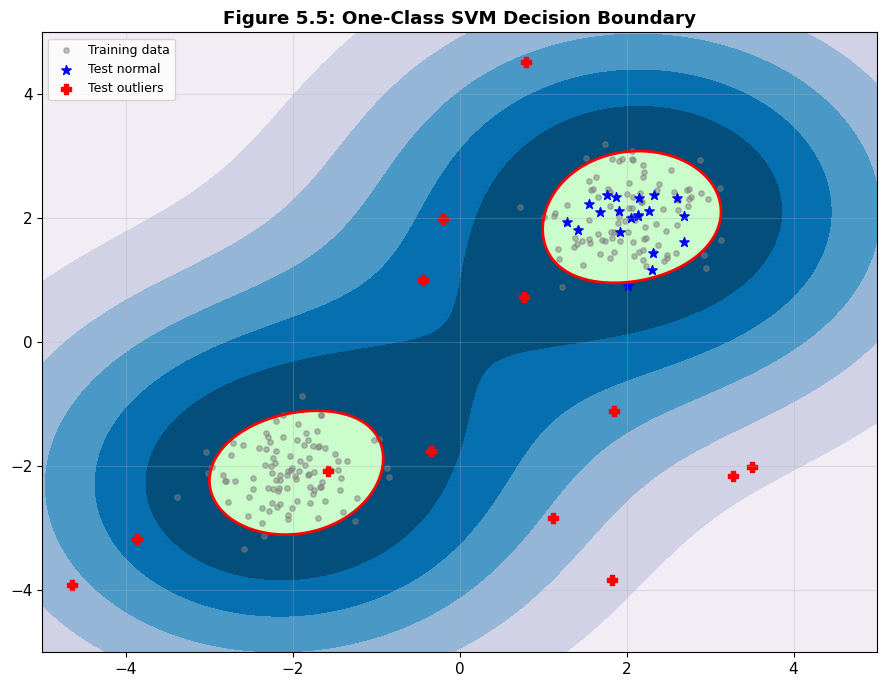

In [8]:
# Listing 5.3: OCSVM with decision boundary visualization
from sklearn.svm import OneClassSVM

np.random.seed(0)
min_range, max_range = -5, 5

# Training data: two clusters
x1 = np.random.normal(loc=2.0, scale=0.5, size=100)
y1 = np.random.normal(loc=2.0, scale=0.5, size=100)
x2 = np.random.normal(loc=-2.0, scale=0.5, size=100)
y2 = np.random.normal(loc=-2.0, scale=0.5, size=100)
X_train_svm = np.column_stack([np.concatenate([x1, x2]), np.concatenate([y1, y2])])

# Test data: normal + outliers
X_test_normal = np.column_stack([np.random.normal(2.0, 0.4, 20), np.random.normal(2.0, 0.4, 20)])
X_test_outlier = np.column_stack([np.random.normal(0.0, 4.0, 20), np.random.normal(0.0, 4.0, 20)])

clf = OneClassSVM(nu=0.1)
clf.fit(X_train_svm)

# Decision function on grid
xx, yy = np.meshgrid(np.linspace(min_range, max_range, 300), np.linspace(min_range, max_range, 300))
dec_func = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, dec_func, levels=np.linspace(dec_func.min(), 0, 7), cmap=plt.cm.PuBu)
ax.contour(xx, yy, dec_func, levels=[0], linewidths=2, colors='red')
ax.contourf(xx, yy, dec_func, levels=[0, dec_func.max()], colors='palegreen', alpha=0.5)

ax.scatter(X_train_svm[:, 0], X_train_svm[:, 1], c='gray', s=15, alpha=0.5, label='Training data')
ax.scatter(X_test_normal[:, 0], X_test_normal[:, 1], c='blue', s=50, marker='*', label='Test normal')
ax.scatter(X_test_outlier[:, 0], X_test_outlier[:, 1], c='red', s=50, marker='P', label='Test outliers')
ax.set_title('Figure 5.5: One-Class SVM Decision Boundary', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(min_range, max_range); ax.set_ylim(min_range, max_range)
plt.tight_layout()

n_err_train = (clf.predict(X_train_svm) == -1).sum()
n_err_normal = (clf.predict(X_test_normal) == -1).sum()
n_err_outlier = (clf.predict(X_test_outlier) == 1).sum()
print(f"Figure 5.5: OCSVM decision boundary (nu=0.1).")
print(f"  Training errors: {n_err_train}/200 outside boundary")
print(f"  Test normal errors: {n_err_normal}/20 flagged as outlier")
print(f"  Test outlier errors: {n_err_outlier}/20 missed (inside boundary)")

This recreates the book's Figure 5.5. The red contour is the **decision boundary** learned from the training data. The green region is "normal"; the blue-purple region is "outlier" with color intensity indicating distance from the boundary.

Key observations:
- The boundary wraps tightly around both training clusters
- Some training points (controlled by $\text{nu} = 0.1$) fall outside -- this is expected and useful for handling noise
- Most test normal points (blue stars) fall inside the boundary
- Most test outlier points (red plus signs) fall outside
- The boundary scores increase with distance, providing a continuous measure of outlierness

**OCSVM is best for novelty detection**: train on known-good data, then flag anything different in new data. If trained on contaminated data, the boundary will expand to include the outliers, reducing detection ability.

## 5.5 Elliptic Envelope and Mahalanobis Distance

**Elliptic Envelope** fits the tightest multivariate ellipse around the data and flags points outside it. This is a parametric approach: it assumes the data forms a single multivariate Gaussian cluster.

The key concept underlying Elliptic Envelope is the **Mahalanobis distance** -- a distance metric that accounts for feature variances and correlations:

$$D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})}$$

where $\boldsymbol{\mu}$ is the data center and $\mathbf{\Sigma}$ is the **covariance matrix**. Unlike Euclidean distance, Mahalanobis distance "stretches" the space so that features with high variance or strong correlations are weighted appropriately.

Figure 5.6: Euclidean vs Mahalanobis distance.
  Euclidean: A=2.12, B=2.69 (A appears less outlierish)
  Mahalanobis: A=4.80, B=5.34 (A correctly scores higher)


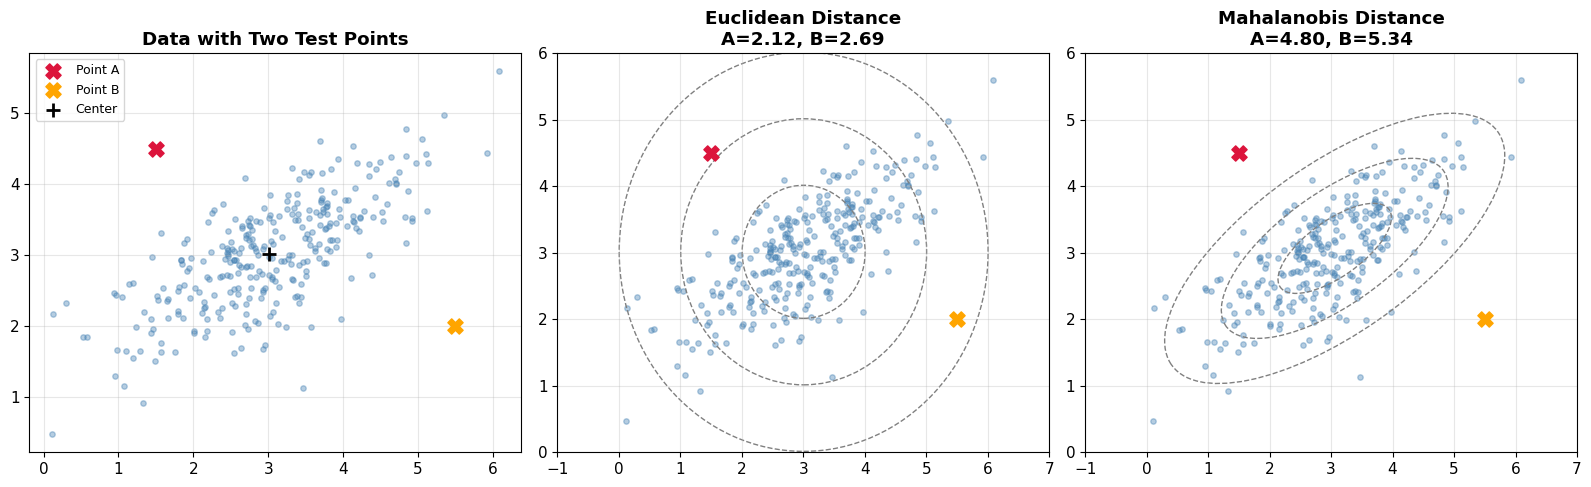

In [9]:
# Figure 5.6: Euclidean vs Mahalanobis distance
np.random.seed(42)

# Skewed, correlated data
cov_skew = [[1.0, 0.8], [0.8, 0.3]]
data_skew = np.random.multivariate_normal([3, 3], cov_skew, 300)

# Two test points
point_A = np.array([[1.5, 4.5]])  # unusual given the correlation
point_B = np.array([[5.5, 2.0]])  # less unusual despite same Euclidean distance

center = data_skew.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: raw data
ax = axes[0]
ax.scatter(data_skew[:, 0], data_skew[:, 1], alpha=0.4, s=15, c='steelblue')
ax.scatter(*point_A[0], c='crimson', s=120, marker='X', zorder=5, label='Point A')
ax.scatter(*point_B[0], c='orange', s=120, marker='X', zorder=5, label='Point B')
ax.scatter(*center, c='black', s=100, marker='+', linewidths=2, zorder=5, label='Center')
ax.set_title('Data with Two Test Points', fontweight='bold')
ax.legend(fontsize=9)

# Middle: Euclidean distance rings
ax = axes[1]
ax.scatter(data_skew[:, 0], data_skew[:, 1], alpha=0.4, s=15, c='steelblue')
for r in [1, 2, 3]:
    circle = plt.Circle(center, r, fill=False, color='gray', linestyle='--')
    ax.add_patch(circle)
ax.scatter(*point_A[0], c='crimson', s=120, marker='X', zorder=5)
ax.scatter(*point_B[0], c='orange', s=120, marker='X', zorder=5)
d_euc_A = np.sqrt(((point_A[0] - center)**2).sum())
d_euc_B = np.sqrt(((point_B[0] - center)**2).sum())
ax.set_title(f'Euclidean Distance\nA={d_euc_A:.2f}, B={d_euc_B:.2f}', fontweight='bold')
ax.set_xlim(-1, 7); ax.set_ylim(0, 6)

# Right: Mahalanobis distance (elliptic contours)
ax = axes[2]
ax.scatter(data_skew[:, 0], data_skew[:, 1], alpha=0.4, s=15, c='steelblue')
cov_est = MinCovDet(random_state=42).fit(data_skew)
# Draw elliptic contours
from matplotlib.patches import Ellipse
eigenvalues, eigenvectors = np.linalg.eigh(cov_est.covariance_)
angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
for n_std in [1, 2, 3]:
    w, h = 2 * n_std * np.sqrt(eigenvalues)
    ell = Ellipse(xy=cov_est.location_, width=w, height=h, angle=angle,
                  fill=False, color='gray', linestyle='--')
    ax.add_patch(ell)
mah_A = cov_est.mahalanobis(point_A)[0]
mah_B = cov_est.mahalanobis(point_B)[0]
ax.scatter(*point_A[0], c='crimson', s=120, marker='X', zorder=5)
ax.scatter(*point_B[0], c='orange', s=120, marker='X', zorder=5)
ax.set_title(f'Mahalanobis Distance\nA={np.sqrt(mah_A):.2f}, B={np.sqrt(mah_B):.2f}', fontweight='bold')
ax.set_xlim(-1, 7); ax.set_ylim(0, 6)

plt.tight_layout()
print(f"Figure 5.6: Euclidean vs Mahalanobis distance.")
print(f"  Euclidean: A={d_euc_A:.2f}, B={d_euc_B:.2f} (A appears less outlierish)")
print(f"  Mahalanobis: A={np.sqrt(mah_A):.2f}, B={np.sqrt(mah_B):.2f} (A correctly scores higher)")

This recreates the book's Figure 5.6. The Euclidean distance (middle panel, circular contours) treats both dimensions equally and finds A and B at similar distances from the center. But given the data's strong positive correlation, **Point A is genuinely more unusual** -- it violates the correlation pattern.

The Mahalanobis distance (right panel, elliptical contours) accounts for the covariance structure and correctly scores A as more distant. The elliptical contours align with the data's natural shape, providing a more meaningful measure of outlierness.

**Elliptic Envelope** uses Mahalanobis distance internally, with robust covariance estimation (MCD) to resist the influence of outliers on the covariance matrix itself.

Figure 5.7: Elliptic Envelope detection.
  Flagged: 51 outliers out of 505 points


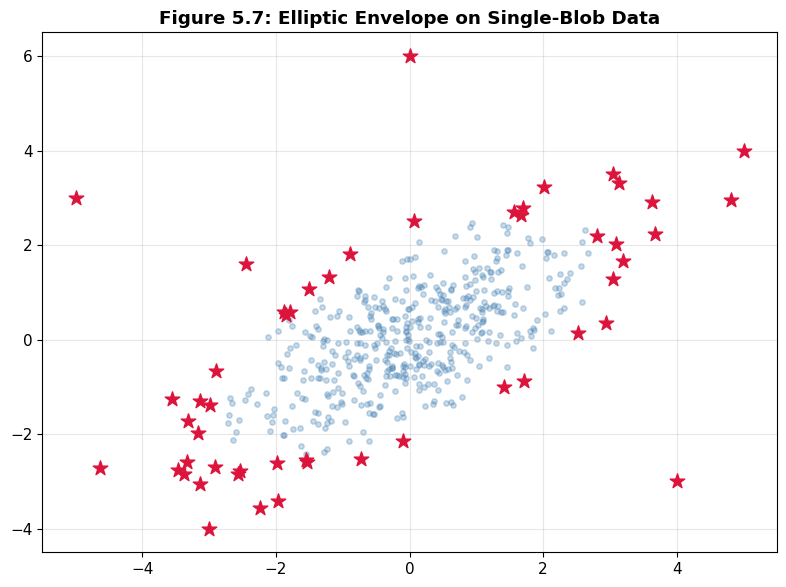

In [10]:
# Elliptic Envelope on single-blob data
np.random.seed(42)
blob_data = np.random.multivariate_normal([0, 0], [[2, 1.2], [1.2, 1.5]], 500)
# Add some outliers
outlier_pts = np.array([[-5, 3], [4, -3], [5, 4], [-3, -4], [0, 6]])
X_ee = np.vstack([blob_data, outlier_pts])

ee = EllipticEnvelope(random_state=42)
ee_pred = ee.fit_predict(X_ee)
ee_outlier = ee_pred == -1

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_ee[~ee_outlier, 0], X_ee[~ee_outlier, 1], alpha=0.3, s=15, c='steelblue')
ax.scatter(X_ee[ee_outlier, 0], X_ee[ee_outlier, 1], c='crimson', s=120, marker='*', zorder=5)
ax.set_title('Figure 5.7: Elliptic Envelope on Single-Blob Data', fontweight='bold')
plt.tight_layout()

print(f"Figure 5.7: Elliptic Envelope detection.")
print(f"  Flagged: {ee_outlier.sum()} outliers out of {len(X_ee)} points")

The Elliptic Envelope correctly identifies the planted outliers around the periphery of the single blob. For data that is genuinely in a single, roughly Gaussian cluster, this is one of the fastest and most effective methods available. Its limitations emerge with multi-cluster data or strongly non-Gaussian distributions, where the single-ellipse assumption fails.

## 5.6 Gaussian Mixture Models

**GMMs** extend Elliptic Envelope to **multiple clusters**, fitting a separate multivariate Gaussian to each. Each cluster has its own center, covariance matrix, and weight (the fraction of data it generates). The outlier score is the **log-likelihood** of each point under the mixture -- points far from all cluster centers receive low likelihood.

GMM uses **Expectation-Maximization (EM)** to iteratively find the best parameters. The number of components (clusters) can be selected using the **Bayesian Information Criterion (BIC)**, which balances model fit against complexity.

GMM Results:
  Best n_components: 4 (BIC = 4373.1)
  Component weights: [0.034 0.322 0.322 0.323]
  Outliers flagged: 16 (3% threshold)


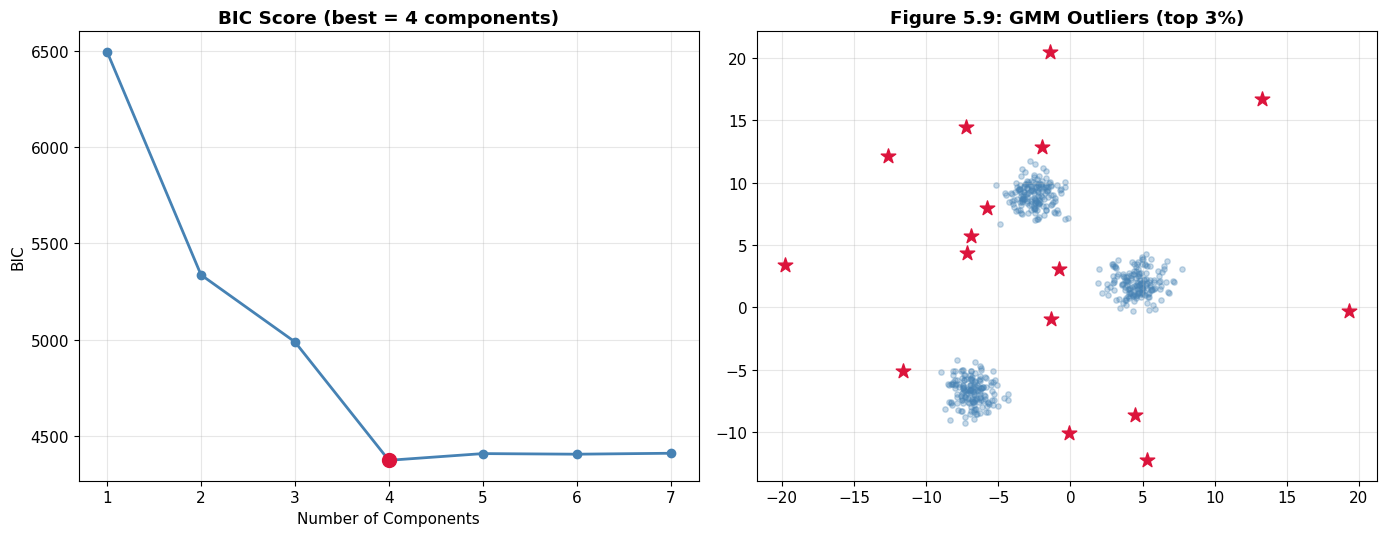

In [11]:
# Listing 5.9: GMM for outlier detection
from sklearn.mixture import GaussianMixture

np.random.seed(0)
vals_in, _ = make_blobs(n_samples=500, centers=3, n_features=2, cluster_std=1, random_state=42)
vals_out, _ = make_blobs(n_samples=15, centers=2, n_features=2, cluster_std=10, random_state=42)
X_gmm = np.vstack([vals_in, vals_out])

# Select best number of components using BIC
best_n, best_bic = -1, np.inf
bic_scores = {}
for n_comp in range(1, 8):
    gmm_test = GaussianMixture(n_components=n_comp, n_init=5, random_state=42)
    gmm_test.fit(X_gmm)
    bic = gmm_test.bic(X_gmm)
    bic_scores[n_comp] = bic
    if bic < best_bic:
        best_bic, best_n = bic, n_comp

# Fit with best n_components
gmm = GaussianMixture(n_components=best_n, n_init=5, random_state=42)
gmm.fit(X_gmm)
gmm_scores = gmm.score_samples(X_gmm)

pct_threshold = np.percentile(gmm_scores, 3.0)
gmm_outliers = gmm_scores < pct_threshold

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# BIC plot
ax = axes[0]
ax.plot(list(bic_scores.keys()), list(bic_scores.values()), 'o-', color='steelblue', linewidth=2)
ax.scatter([best_n], [best_bic], c='crimson', s=100, zorder=5)
ax.set_xlabel('Number of Components')
ax.set_ylabel('BIC')
ax.set_title(f'BIC Score (best = {best_n} components)', fontweight='bold')

# Outlier detection
ax = axes[1]
ax.scatter(X_gmm[~gmm_outliers, 0], X_gmm[~gmm_outliers, 1], alpha=0.3, s=15, c='steelblue')
ax.scatter(X_gmm[gmm_outliers, 0], X_gmm[gmm_outliers, 1], c='crimson', s=120, marker='*', zorder=5)
ax.set_title(f'Figure 5.9: GMM Outliers (top 3%)', fontweight='bold')

plt.tight_layout()

print(f"GMM Results:")
print(f"  Best n_components: {best_n} (BIC = {best_bic:.1f})")
print(f"  Component weights: {np.round(gmm.weights_, 3)}")
print(f"  Outliers flagged: {gmm_outliers.sum()} (3% threshold)")

The BIC selects the optimal number of components, balancing fit quality against model complexity. The GMM then produces **log-likelihood scores** for each point: those in low-likelihood regions (far from all cluster centers) are flagged as outliers.

GMM is a **soft clustering** method -- each point gets a probability of belonging to each cluster, not a hard assignment. This makes it more nuanced than DBSCAN for cluster-based outlier detection. Points that are somewhat plausible under multiple clusters receive higher likelihoods than points that are improbable under all clusters.

**GMM vs. Elliptic Envelope**: GMM handles multi-cluster data; Elliptic Envelope assumes a single cluster. When the data truly is a single blob, both perform equivalently (GMM with $n=1$ is mathematically identical to Elliptic Envelope).

## 5.7 Comparing the Detectors

Let's run all four scikit-learn detectors plus GMM on the same dataset and compare.

Detector Comparison (AUROC):
  Elliptic Envelope         0.9996
  OCSVM                     0.9991
  Isolation Forest          0.9593
  GMM (n=2)                 0.9394
  LOF (k=20)                0.7024


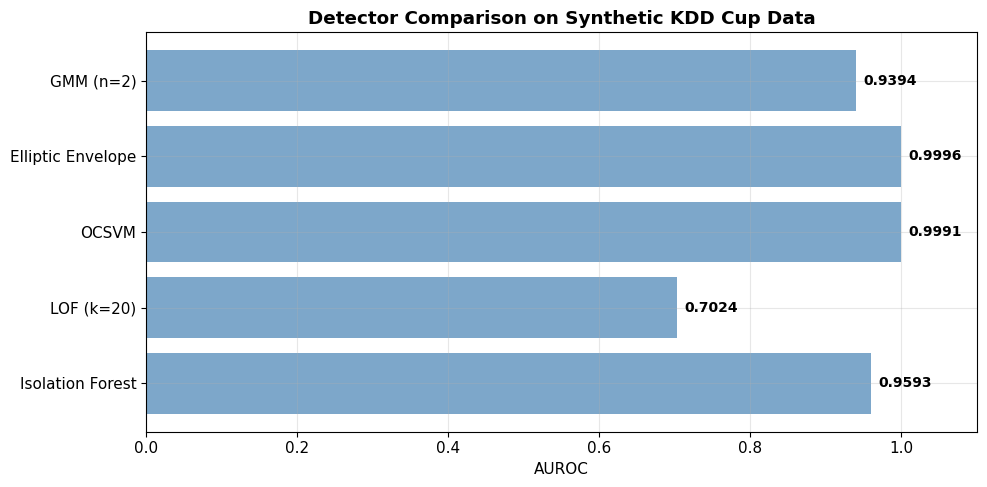

In [12]:
# Head-to-head comparison on synthetic KDD Cup data
results = {}

# IF (no scaling needed)
det_if = IsolationForest(random_state=42)
det_if.fit(df_kdd)
s = det_if.score_samples(df_kdd)
results['Isolation Forest'] = roc_auc_score(y_kdd, -s)

# LOF (scaled)
det_lof = LocalOutlierFactor(n_neighbors=20)
det_lof.fit_predict(X_kdd_scaled)
results['LOF (k=20)'] = roc_auc_score(y_kdd, -det_lof.negative_outlier_factor_)

# OCSVM (scaled, trained on clean subset)
X_tr, X_te, y_tr, y_te = train_test_split(X_kdd_scaled, y_kdd, test_size=0.8, random_state=42)
X_tr_clean = X_tr[y_tr == 0]  # train on normals only
det_svm = OneClassSVM(nu=0.05)
det_svm.fit(X_tr_clean[:2000])  # sample for speed
s_svm = det_svm.score_samples(X_te)
results['OCSVM'] = roc_auc_score(y_te, -s_svm)

# Elliptic Envelope (scaled)
det_ee = EllipticEnvelope(random_state=42)
det_ee.fit(X_kdd_scaled)
s_ee = det_ee.score_samples(X_kdd_scaled)
results['Elliptic Envelope'] = roc_auc_score(y_kdd, -s_ee)

# GMM (scaled)
gmm_det = GaussianMixture(n_components=2, n_init=5, random_state=42)
gmm_det.fit(X_kdd_scaled)
s_gmm = gmm_det.score_samples(X_kdd_scaled)
results['GMM (n=2)'] = roc_auc_score(y_kdd, -s_gmm)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
scores_plot = list(results.values())
colors = ['steelblue' if s < max(scores_plot) else 'crimson' for s in scores_plot]
bars = ax.barh(names, scores_plot, color='steelblue', alpha=0.7)
for bar, score in zip(bars, scores_plot):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('AUROC')
ax.set_title('Detector Comparison on Synthetic KDD Cup Data', fontweight='bold')
ax.set_xlim(0, 1.1)

plt.tight_layout()

print("Detector Comparison (AUROC):")
for name, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {name:25s} {score:.4f}")

The comparison reveals several patterns consistent with the book's findings:

**Isolation Forest** typically performs well across datasets because it makes no distributional assumptions and handles many features gracefully. Its tree-based approach sidesteps the distance concentration problem.

**OCSVM** can achieve excellent results when trained on clean data (as here, where we filtered to normal-only training data). In practice, clean data is rare, which limits OCSVM's applicability.

**LOF** may underperform when the target outliers are globally unusual (as in this synthetic dataset where attacks have shifted means). LOF excels when outliers are *locally* unusual but globally plausible.

**Elliptic Envelope** assumes a single Gaussian cluster, which may not match the data structure. It works best when this assumption holds.

**GMM** extends Elliptic Envelope to multiple clusters and often performs competitively, especially when the data has natural cluster structure.

In [13]:
# Summary comparison table
summary = pd.DataFrame({
    'Detector': ['Isolation Forest', 'LOF', 'One-Class SVM', 'Elliptic Envelope', 'GMM'],
    'Type': ['Tree/Isolation', 'Density (local)', 'Boundary', 'Parametric', 'Parametric/Cluster'],
    'Scaling Needed': ['No', 'Yes', 'Yes', 'Yes', 'Yes'],
    'Best For': ['General purpose', 'Local outliers', 'Novelty detection', 'Single Gaussian cluster', 'Multi-cluster'],
    'Main Limitation': ['Uninterpretable', 'Sensitive to k', 'Needs clean train data', 'Single cluster only', 'Needs n_components'],
    'Speed': ['Very fast O(n)', 'Moderate O(n*k)', 'Slow (large data)', 'Fast', 'Moderate'],
    'Curse of Dim.': ['Moderate', 'High', 'High', 'Moderate', 'Moderate']
})
print("scikit-learn Detector Summary:")
print(summary.to_string(index=False))

scikit-learn Detector Summary:
         Detector               Type Scaling Needed                Best For        Main Limitation             Speed Curse of Dim.
 Isolation Forest     Tree/Isolation             No         General purpose        Uninterpretable    Very fast O(n)      Moderate
              LOF    Density (local)            Yes          Local outliers         Sensitive to k   Moderate O(n*k)          High
    One-Class SVM           Boundary            Yes       Novelty detection Needs clean train data Slow (large data)          High
Elliptic Envelope         Parametric            Yes Single Gaussian cluster    Single cluster only              Fast      Moderate
              GMM Parametric/Cluster            Yes           Multi-cluster     Needs n_components          Moderate      Moderate


## 5.8 Chapter Summary

This chapter covered scikit-learn's complete outlier detection toolkit:

**Isolation Forest** -- The most generally applicable detector. Tree-based isolation means no scaling, no distance calculations, fast execution, and robustness to parameters. Start with IF and use it as a baseline.

**Local Outlier Factor** -- The canonical local density method. Compares each point's density to its neighbors' densities, excelling at multi-density data. Sensitive to the choice of $k$ (n_neighbors).

**One-Class SVM** -- Learns a tight decision boundary around normal data. Best for novelty detection with clean training data. The `nu` parameter controls boundary tightness.

**Elliptic Envelope** -- Fits a multivariate Gaussian ellipse using robust covariance estimation (MCD). Fast and effective for single-cluster data. Limited by the Gaussian assumption.

**Gaussian Mixture Models** -- Extends Elliptic Envelope to multiple clusters via soft clustering. Uses BIC to select the number of components. Often an excellent choice when the data has natural cluster structure.

**BallTree / KDTree** -- Efficient nearest-neighbor structures that underpin KNN, Radius, LOF, and KDE implementations. BallTree is preferred for higher dimensions; KDTree for lower.

**Practical guidance:**
- Always try **Isolation Forest first** -- it is fast, robust, and handles many features
- Add **LOF** when local outliers matter (multi-density data)
- Use **OCSVM** when clean training data is available for novelty detection
- Use **Elliptic Envelope / GMM** when the data has clear cluster structure
- **Combine multiple detectors** in an ensemble (Chapter 12) for comprehensive detection

In the next chapter, we explore **PyOD** -- a library dedicated entirely to outlier detection, providing dozens of additional algorithms beyond what scikit-learn offers.

## Appendix: KDD Cup Dataset Examples (Run on Google Colab)

The following cells reproduce the book's exact examples using the KDD Cup dataset, which requires internet access to download.

In [14]:
# Run on Google Colab -- Listing 5.1: Isolation Forest on KDD Cup
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_kddcup99
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix, roc_auc_score

np.random.seed(0)
X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                       return_X_y=True, as_frame=True)
y = (y != b"normal.").astype(np.int32)

enc = OrdinalEncoder()
X = enc.fit_transform(X)

det = IsolationForest()
det.fit(X)

# Binary predictions
pred = pd.Series(det.predict(X)).map({1: 0, -1: 1})
print("Confusion Matrix:")
print(confusion_matrix(y, pred))

# AUROC
pred_scores = det.score_samples(X)
min_score, max_score = pred_scores.min(), pred_scores.max()
pred_norm = [1.0 - (x - min_score) / (max_score - min_score) for x in pred_scores]
print(f"AUROC: {roc_auc_score(y, pred_norm):.4f}")

Confusion Matrix:
[[89123  8155]
 [   29  3348]]
AUROC: 0.9520


k=5...
  AUROC: 0.3496
k=10...
  AUROC: 0.3369
k=20...
  AUROC: 0.3391
k=30...
  AUROC: 0.3181
k=40...
  AUROC: 0.3125
k=50...
  AUROC: 0.3219
k=60...
  AUROC: 0.3280
k=70...
  AUROC: 0.3264
k=80...
  AUROC: 0.3254


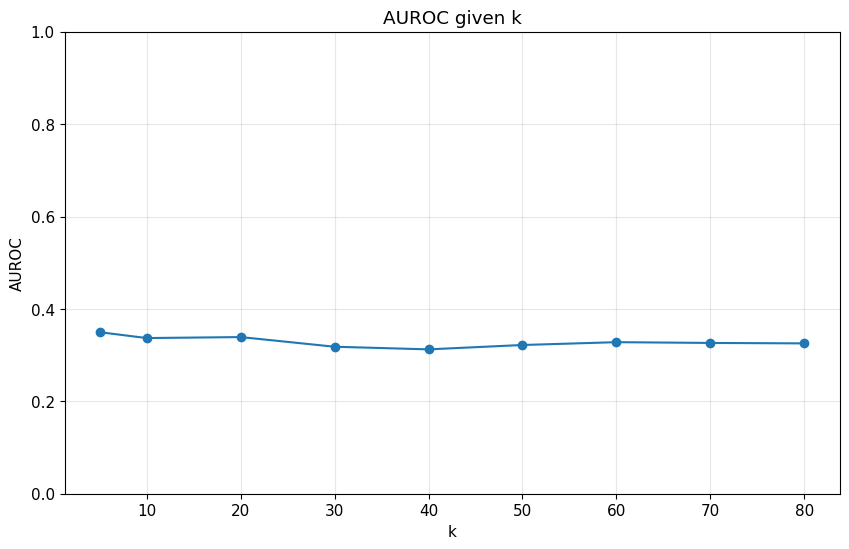

In [15]:
# Run on Google Colab -- Listing 5.2: LOF on KDD Cup with k tuning
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_kddcup99
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                       return_X_y=True, as_frame=True)
y = (y != b"normal.").astype(np.int32)

cat_columns = ["protocol_type", "service", "flag"]
X_cat = pd.get_dummies(X[cat_columns]).reset_index(drop=True)
numeric_cols = [x for x in X.columns if x not in cat_columns]
X_num = pd.DataFrame(RobustScaler().fit_transform(X[numeric_cols]), columns=numeric_cols)
X = pd.concat([X_cat, X_num], axis=1)

scores = []
for k in [5, 10, 20, 30, 40, 50, 60, 70, 80]:
    print(f"k={k}...")
    det = LocalOutlierFactor(n_neighbors=k)
    det.fit_predict(X)
    r = roc_auc_score(y, 1.0 - det.negative_outlier_factor_)
    scores.append(r)
    print(f"  AUROC: {r:.4f}")

plt.plot([5, 10, 20, 30, 40, 50, 60, 70, 80], scores, 'o-')
plt.xlabel('k'); plt.ylabel('AUROC'); plt.title('AUROC given k')
plt.ylim(0, 1); plt.show()

In [16]:
# Run on Google Colab -- Listing 5.4: OneClassSVM on KDD Cup
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score

X, y = fetch_kddcup99(subset="SA", percent10=True, random_state=42,
                       return_X_y=True, as_frame=True)
y = (y != b"normal.").astype(np.int32)

cat_columns = ["protocol_type", "service", "flag"]
X_cat = pd.get_dummies(X[cat_columns]).reset_index(drop=True)
numeric_cols = [x for x in X.columns if x not in cat_columns]
X_num = pd.DataFrame(RobustScaler().fit_transform(X[numeric_cols]), columns=numeric_cols)
X = pd.concat([X_cat, X_num], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.90, random_state=42)
X_train = X_train.loc[y_train[y_train == 0].index]  # train on normals only

det = OneClassSVM()
det.fit(X_train)
pred = det.score_samples(X_test)
pred_norm = [1.0 - (x - min(pred)) / (max(pred) - min(pred)) for x in pred]
print(f"AUROC: {roc_auc_score(y_test, pred_norm):.4f}")

AUROC: 0.9254
